In [98]:
import pandas as pd;
import matplotlib.pyplot as plt
import numpy as np;
import ssl
lefthanded_data = pd.read_csv("data.csv")
lefthanded_data.head()

,Age,Male,Female
0,10,12.717558,12.198041
1,11,15.318830,11.144804
2,12,14.808281,11.549240
3,13,13.793744,11.276442
4,14,15.156304,11.572906


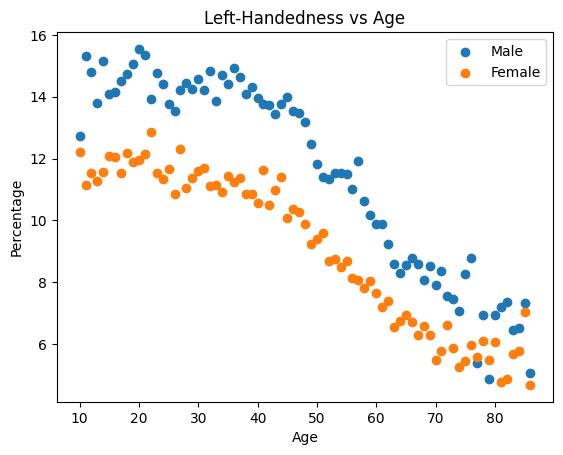

In [99]:
plt.scatter(lefthanded_data["Age"], lefthanded_data["Male"], label="Male")
plt.scatter(lefthanded_data["Age"], lefthanded_data["Female"], label="Female")

plt.title("Left-Handedness vs Age")
plt.xlabel("Age")
plt.ylabel("Percentage")
plt.legend()
plt.show()

In [100]:
lefthanded_data["Birth_year"] = 1986 - lefthanded_data["Age"]

In [101]:
lefthanded_data["Mean_lh"] = (lefthanded_data["Male"] + lefthanded_data["Female"])/ 2

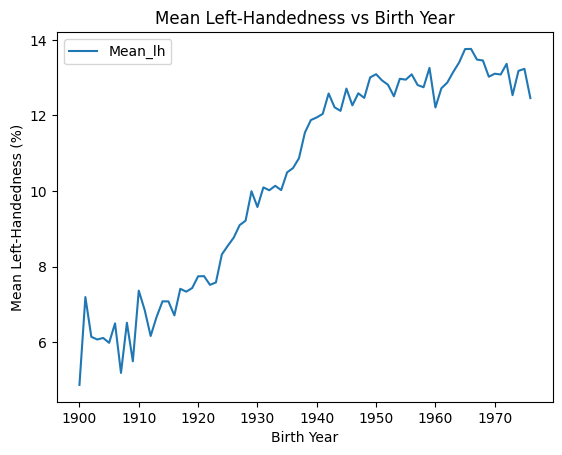

In [102]:
lefthanded_data.plot( x="Birth_year",
    y="Mean_lh")
plt.title("Mean Left-Handedness vs Birth Year")
plt.xlabel("Birth Year")
plt.ylabel("Mean Left-Handedness (%)")
plt.show()

In [103]:
import numpy as np

# Calculate average left-handedness rates
# Last 10 values → early 1900s
early_1900s_rate = lefthanded_data['Mean_lh'].tail(10).mean()

# First 10 values → late 1900s
late_1900s_rate = lefthanded_data['Mean_lh'].head(10).mean()

# Function to compute probability of being left-handed given age
def P_lh_given_A(ages, study_year):
    P_return = np.zeros(len(ages))
    
    for i, age in enumerate(ages):
        birth_year = study_year - age
        
        # Assign probability based on birth year
        if birth_year < 1920:
            P_return[i] = early_1900s_rate / 100
        else:
            P_return[i] = late_1900s_rate / 100
            
    return P_return

# Test the function
test_ages = np.array([20, 40, 60, 80])
print("Test P_lh_given_A:", P_lh_given_A(test_ages, 1990))

Test P_lh_given_A: [0.13090615 0.13090615 0.13090615 0.06007159]


In [104]:
ssl._create_default_https_context = ssl._create_unverified_context

In [105]:
data_url_2 = "https://gist.githubusercontent.com/mbonsma/2f4076aab6820ca1807f4e29f75f18ec/raw/62f3ec07514c7e31f5979beeca86f19991540796/cdc_vs00199_table310.tsv"


In [106]:
death_distribution_data = pd.read_csv(
    data_url_2,
    sep='\t',
    skiprows=[1]
)
death_distribution_data.head()

,Age,Both Sexes,Male,Female
0,0,27937.0,15646.0,12291.0
1,1,1989.0,1103.0,886.0
2,2,1376.0,797.0,579.0
3,3,1046.0,601.0,445.0
4,4,838.0,474.0,364.0


In [107]:
death_distribution_data = death_distribution_data.dropna(subset=["Both Sexes"])

<Axes: title={'center': 'Number of Deaths by Age'}, xlabel='Age', ylabel='Number of Deaths'>

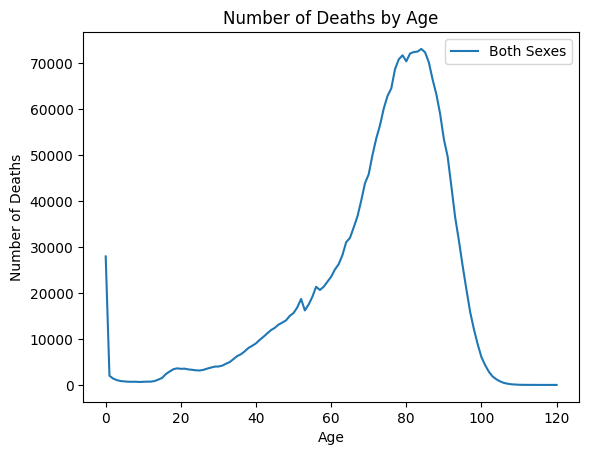

In [108]:
death_distribution_data.plot(
    x="Age",
    y="Both Sexes",
    kind="line",
    title="Number of Deaths by Age",
    xlabel="Age",
    ylabel="Number of Deaths"
)

In [109]:
# Function to compute overall probability of being left-handed
def P_lh(death_distribution_data, study_year):
    
    # Extract ages and number of deaths
    ages = death_distribution_data['Age'].values
    deaths = death_distribution_data['Both Sexes'].values
    
    # Compute P(LH | A)
    P_LH_given_A = P_lh_given_A(ages, study_year)
    
    # Multiply deaths by corresponding probabilities
    p_list = deaths * P_LH_given_A
    
    # Sum numerator
    p = np.sum(p_list)
    
    # Total number of deaths
    total = np.sum(deaths)
    
    # Return overall probability
    return p / total

# Test the function
print("P(LH):", P_lh(death_distribution_data, 1990))

P(LH): 0.08454802611911551


In [110]:
# Function to compute probability of dying at age A given left-handedness
def P_A_given_lh(ages, death_distribution_data, study_year=1990):
    
    # Extract death counts
    deaths = death_distribution_data['Both Sexes'].values
    total_deaths = np.sum(deaths)
    
    # Compute P(A): probability of dying at age A
    P_A = deaths / total_deaths
    
    # Compute overall probability of left-handedness
    P_LH = P_lh(death_distribution_data, study_year)
    
    # Compute P(LH | A)
    P_LH_given_A = P_lh_given_A(ages, study_year)
    
    # Apply Bayes' theorem
    P_A_given_LH = (P_LH_given_A * P_A) / P_LH
    
    return P_A_given_LH

# Test the function
ages = death_distribution_data['Age'].values
result = P_A_given_lh(ages, death_distribution_data, 1990)

print("First 10 values of P(A | LH):")
print(result[:10])

First 10 values of P(A | LH):
[0.01809043 0.00128796 0.00089102 0.00067733 0.00054264 0.00049408
 0.00045069 0.00044227 0.0004481  0.00041443]


In [111]:
# Function to compute probability of dying at age A given right-handedness
def P_A_given_rh(ages, death_distribution_data, study_year=1990):
    
    # Extract number of deaths
    deaths = death_distribution_data['Both Sexes'].values
    total_deaths = np.sum(deaths)
    
    # Compute P(A)
    P_A = deaths / total_deaths
    
    # Compute P(LH) then P(RH)
    P_LH = P_lh(death_distribution_data, study_year)
    P_RH = 1 - P_LH
    
    # Compute P(LH | A) then P(RH | A)
    P_LH_given_A = P_lh_given_A(ages, study_year)
    P_RH_given_A = 1 - P_LH_given_A
    
    # Apply Bayes
    P_A_given_RH = (P_RH_given_A * P_A) / P_RH
    
    return P_A_given_RH

In [112]:
ages = death_distribution_data['Age'].values

result_rh = P_A_given_rh(ages, death_distribution_data, 1990)

print("First 10 values of P(A | RH):")
print(result_rh[:10])

First 10 values of P(A | RH):
[0.01109235 0.00078973 0.00054634 0.00041531 0.00033273 0.00030295
 0.00027635 0.00027118 0.00027476 0.00025411]


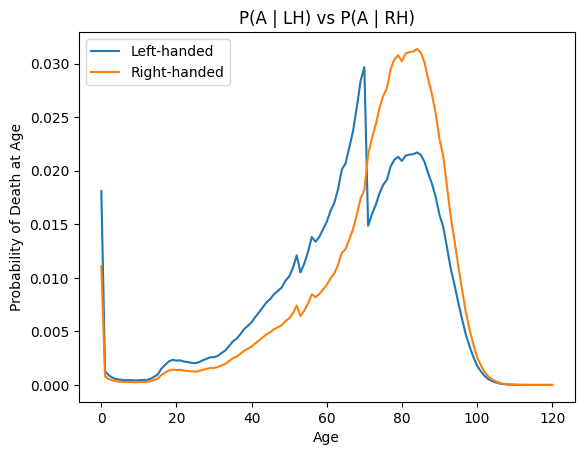

In [113]:
# Get ages
ages = death_distribution_data['Age'].values

# Calculate probabilities
P_A_given_lh_vals = P_A_given_lh(ages, death_distribution_data, 1990)
P_A_given_rh_vals = P_A_given_rh(ages, death_distribution_data, 1990)

# Plot the results
plt.plot(ages, P_A_given_lh_vals, label='Left-handed')
plt.plot(ages, P_A_given_rh_vals, label='Right-handed')

# Add labels and title
plt.xlabel("Age")
plt.ylabel("Probability of Death at Age")
plt.title("P(A | LH) vs P(A | RH)")

# Add legend
plt.legend()

# Show plot
plt.show()

In [114]:
# Calculate average age for left-handed
average_lh_age = np.nansum(ages * P_A_given_lh_vals)

# Calculate average age for right-handed
average_rh_age = np.nansum(ages * P_A_given_rh_vals)

# Print results
print("Average age (Left-handed):", round(average_lh_age, 2))
print("Average age (Right-handed):", round(average_rh_age, 2))

# Difference
difference = average_rh_age - average_lh_age
print("Difference:", round(difference, 2))


Average age (Left-handed): 66.55
Average age (Right-handed): 72.9
Difference: 6.35


In [115]:
ages = death_distribution_data['Age'].values

P_A_given_lh_vals = P_A_given_lh(ages, death_distribution_data, 1990)
P_A_given_rh_vals = P_A_given_rh(ages, death_distribution_data, 1990)

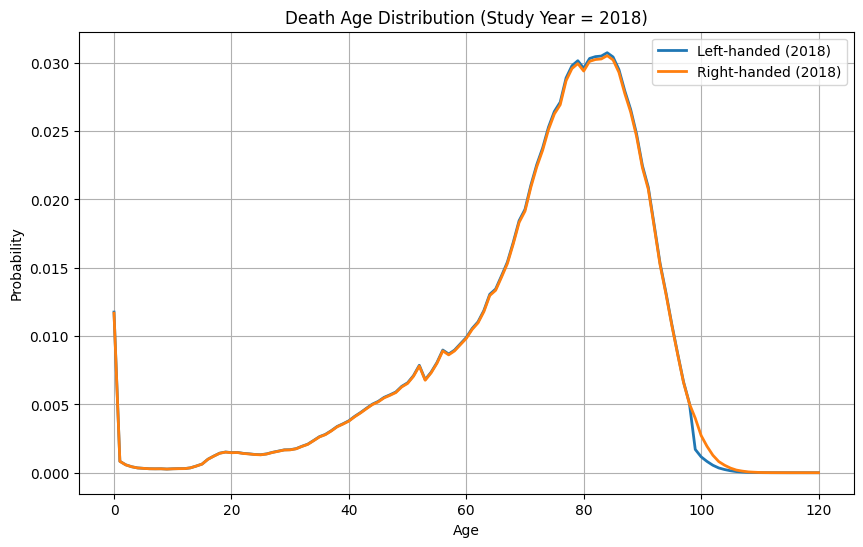

In [116]:
# Get ages
ages = death_distribution_data['Age'].values

# Recalculate probabilities using study_year = 2018
P_A_given_lh_2018 = P_A_given_lh(ages, death_distribution_data, study_year=2018)
P_A_given_rh_2018 = P_A_given_rh(ages, death_distribution_data, study_year=2018)

# Plot results
plt.figure(figsize=(10,6))

plt.plot(ages, P_A_given_lh_2018, label='Left-handed (2018)', linewidth=2)
plt.plot(ages, P_A_given_rh_2018, label='Right-handed (2018)', linewidth=2)

plt.xlabel("Age")
plt.ylabel("Probability")
plt.title("Death Age Distribution (Study Year = 2018)")

plt.legend()
plt.grid()

plt.show()


In [117]:
avg_lh_2018 = np.nansum(ages * P_A_given_lh_2018)
avg_rh_2018 = np.nansum(ages * P_A_given_rh_2018)

print("Average LH (2018):", round(avg_lh_2018, 2))
print("Average RH (2018):", round(avg_rh_2018, 2))
print("Difference:", round(avg_rh_2018 - avg_lh_2018, 2))

Average LH (2018): 72.19
Average RH (2018): 72.39
Difference: 0.2
